# ML Uppgift 1 – California Housing

## Spår A: Regression

Syftet med denna uppgift är att bygga en modell som kan förutsäga `median_house_value` utifrån information om bostadsområden i California Housing-datasetet.

Målet är att genomföra ett enkelt men komplett ML-flöde med dataförståelse, preprocessing, modellering, utvärdering och en kort rekommendation.

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)

## 1. Ladda data
Först läses datasetet in för att få en överblick över innehållet.

In [77]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Dataförståelse

I detta steg undersöks datasetets storlek, datatyper och om det finns saknade värden.

In [78]:
print("Shape:", df.shape)
df.info()

Shape: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [79]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Datasetet innehåller 20640 rader och 10 kolumner. De flesta variabler är numeriska, medan `ocean_proximity` är kategorisk. 

Genom `df.info()` syns också att kolumnen `total_bedrooms` innehåller saknade värden, vilket behöver hanteras innan modellering.

## 3. Explorativ dataanalys (EDA)

Nedan visas två enkla figurer/tabeller för att få en bättre förståelse av datan.

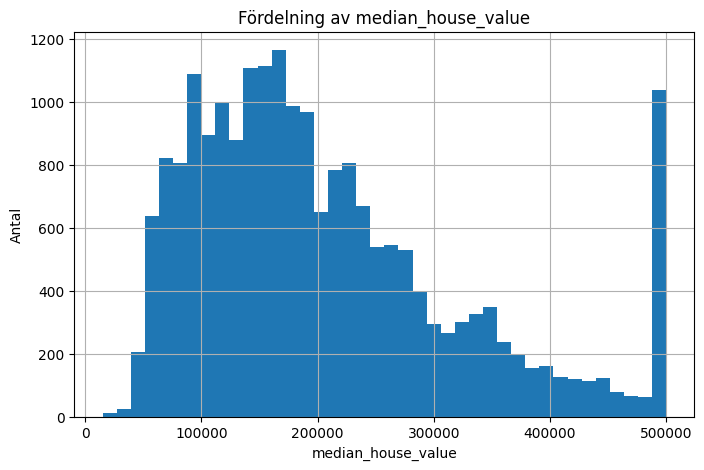

In [80]:
plt.figure(figsize=(8,5))
df["median_house_value"].hist(bins=40)
plt.title("Fördelning av median_house_value")
plt.xlabel("median_house_value")
plt.ylabel("Antal")
plt.show()

Histogrammet visar hur bostadsvärdena är fördelade i datasetet. Fördelningen är inte helt jämn och det finns ett tak vid de högsta värdena, vilket kan påverka modellens träffsäkerhet.

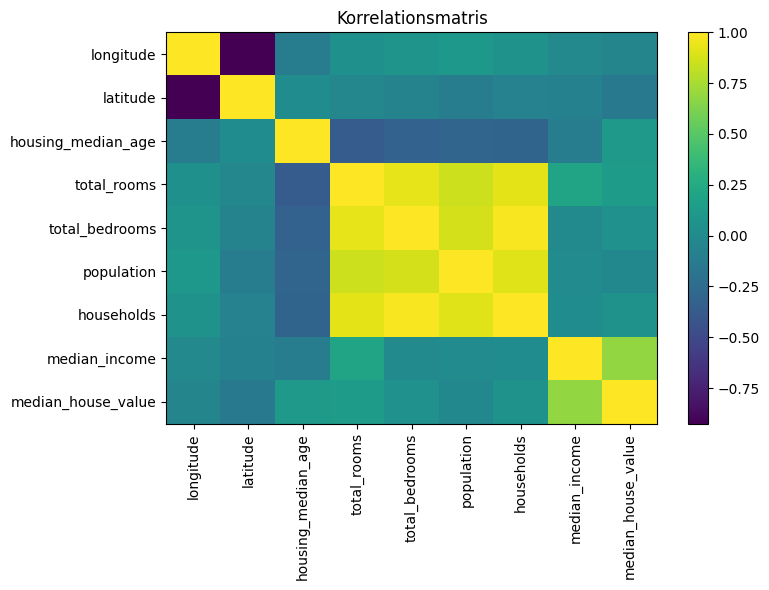

In [81]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Korrelationsmatris")
plt.tight_layout()
plt.show()

Korrelationsmatrisen visar hur de numeriska variablerna hänger ihop med varandra. En viktig observation är att `median_income` verkar ha en relativt stark koppling till `median_house_value`, vilket tyder på att inkomsten i området kan vara viktig för modellen.

## 4. Hantering av saknade värden



In [82]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


Detta är en enkel och effektiv metod när andelen saknade värden är relativt liten. Genom att ta bort dessa rader säkerställs att modellen kan tränas utan problem. Ett alternativ hade varit att använda imputering, till exempel att ersätta saknade värden med medianen, vilket kan vara mer lämpligt om en större del av datan saknas.


## 5. Förberedelse av data

Kolumnen `ocean_proximity` tas bort eftersom den är kategorisk och inte kan användas direkt i denna modell utan vidare bearbetning. I en mer avancerad lösning hade denna variabel kunnat kodas om med till exempel One-Hot Encoding för att behålla informationen.


In [83]:
df = df.drop("ocean_proximity", axis=1)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [84]:
target = "median_house_value"

X = df.drop(columns=[target])
y = df[target]

X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462


## 6. Train/test split

Datan delas upp i träningsdata och testdata. Träningsdatan används för att träna modellen, medan testdatan används för att utvärdera hur modellen fungerar på osedd data.

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16346, 8)
X_test: (4087, 8)
y_train: (16346,)
y_test: (4087,)


## 7. Modellering

För att uppfylla kraven testas tre modeller:
- en enkel baseline-modell
- en linjär modell
- en mer flexibel trädmodell

Modellerna jämförs med hjälp av RMSE.

In [86]:
models = {
    "Dummy": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=SEED)
}

results = []

for name, model in models.items():
    cv = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    
    results.append({
        "Model": name,
        "CV_RMSE": -cv["test_score"].mean()
    })

results_df = pd.DataFrame(results).sort_values("CV_RMSE")
results_df

,Model,CV_RMSE
2,RandomForest,49391.529411
1,LinearRegression,69639.991805
0,Dummy,115041.975476


Resultatet visar att Random Forest-modellen presterar bäst med lägst RMSE. Detta beror på att modellen kan hantera mer komplexa och icke-linjära samband i datan, till skillnad från linjär regression som antar ett linjärt förhållande mellan variablerna. Baseline-modellen (DummyRegressor) används som jämförelse och visar att de andra modellerna faktiskt lär sig från datan.


## 8. Val av modell

Den modell som presterar bäst i jämförelsen väljs för slutlig utvärdering på testdatan.

Modellen har även optimerats med GridSearchCV för att hitta bättre parametrar och förbättra prestandan.

In [87]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: 50005.32251068466


In [88]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 31964.241069243944
RMSE: 49209.54501247107


In [89]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison_df

,Actual,Predicted
0,245800.0,213153.515
1,137900.0,151844.500
2,218200.0,194634.000
3,220800.0,144183.500
4,170500.0,159473.000
5,75000.0,77205.500
6,269400.0,288067.010
7,228900.0,199650.500
8,500001.0,460495.975
9,80800.0,72367.500


MAE visar det genomsnittliga absoluta felet mellan modellens prediktioner och de verkliga värdena. RMSE används också eftersom den straffar större fel mer än mindre fel.

Tabellen med faktiska och predikterade värden visar att modellen kan ge rimliga uppskattningar, men att vissa fel fortfarande finns.

Ett MAE-värde på denna nivå innebär att modellen i genomsnitt gör ett fel på ungefär detta antal dollar vid varje prediktion. RMSE-värdet är högre eftersom det straffar större fel mer, vilket visar att det fortfarande finns vissa större avvikelser i modellens prediktioner.

## 9. Rekommendation

Baserat på jämförelsen mellan modellerna rekommenderas Random Forest-modellen för detta problem, eftersom den gav bäst resultat i utvärderingen.

Modellen kan användas som ett beslutsstöd för att uppskatta bostadsvärden i olika områden utifrån tillgänglig data. Samtidigt bör man komma ihåg att modellen har begränsningar, bland annat att den tränas på historisk data och att den kategoriska kolumnen `ocean_proximity` inte användes i denna enklare lösning.

Random Forest valdes eftersom den gav bäst balans mellan bias och varians i denna uppgift och kunde fånga mer komplexa mönster i datan jämfört med de enklare modellerna.


## 10. Risker och begränsningar

En begränsning i denna lösning är att den kategoriska variabeln `ocean_proximity` togs bort i stället för att kodas om. Det innebär att viss information kan ha gått förlorad.

En annan begränsning är att modellen bygger på historisk data, vilket gör att resultatet kanske inte generaliserar perfekt till nya områden eller framtida marknadsförhållanden.

Ytterligare en begränsning är att modellen inte har optimerats fullt ut och att fler parametrar eller feature engineering skulle kunna förbättra resultatet ytterligare.


## 11. Självreflektion

Det som fungerade bra i uppgiften var att följa ett tydligt ML-flöde från dataförståelse till modellering och utvärdering. Det svåraste var att få miljön och biblioteken att fungera korrekt i VS Code.

Jag bedömer att denna inlämning motsvarar G-nivå eftersom den innehåller ett komplett ML-flöde med EDA, train/test split, minst tre modeller, jämförelse, slutlig utvärdering och en rekommendation.